# Day 13 – Restaurant Branch Performance EDA

## Exploratory Data Analysis using Pandas

This notebook performs EDA on the provided Restaurant Branch Performance Dataset. It covers dataset inspection, descriptive statistics, categorical and numerical distribution analysis, branch/region/store comparisons, and correlation analysis.


## 1. Import Libraries and Load Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/Day13_Restaurant_Branch_Performance_Dataset.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully.
Shape: (350, 22)


,Record_ID,Date,Day,Month,Branch,Region,Store_Type,Staff_Count,Marketing_Spend,Customers,...,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent,Weather,Promotion
0,ST0001,2026-06-06,Saturday,June,Jaipur,North,Express,7,4977.25,172,...,66766.77,27954.29,46554.90,20211.87,29.0,4.44,20.8,70.3,Clear,NaN
1,ST0002,2026-02-10,Tuesday,February,Pune,West,Premium,14,8998.30,285,...,157230.89,63816.59,96813.95,60416.94,27.9,4.56,31.3,70.7,Clear,Loyalty Offer
2,ST0003,2026-03-07,Saturday,March,Delhi,North,Premium,16,10034.97,306,...,155811.96,54874.10,89888.91,65923.05,30.2,4.36,21.4,61.5,Clear,NaN
3,ST0004,2026-05-11,Monday,May,Mumbai,West,Standard,9,5095.84,198,...,80574.05,31429.44,53531.82,27042.23,21.7,4.65,22.9,40.4,Clear,NaN
4,ST0005,2026-01-14,Wednesday,January,Kochi,South,Express,9,6681.82,148,...,56579.89,21759.51,44376.25,12203.64,26.1,4.50,29.0,44.3,Clear,Combo Deal


## 2. Dataset Structure

In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nDataset information:")
df.info()


Shape: (350, 22)

Columns:
['Record_ID', 'Date', 'Day', 'Month', 'Branch', 'Region', 'Store_Type', 'Staff_Count', 'Marketing_Spend', 'Customers', 'Orders', 'Average_Bill', 'Revenue', 'Food_Cost', 'Operating_Cost', 'Profit', 'Avg_Delivery_Min', 'Customer_Rating', 'Temperature_C', 'Humidity_Percent', 'Weather', 'Promotion']

Data types:
Record_ID            object
Date                 object
Day                  object
Month                object
Branch               object
Region               object
Store_Type           object
Staff_Count           int64
Marketing_Spend     float64
Customers             int64
Orders                int64
Average_Bill        float64
Revenue             float64
Food_Cost           float64
Operating_Cost      float64
Profit              float64
Avg_Delivery_Min    float64
Customer_Rating     float64
Temperature_C       float64
Humidity_Percent    float64
Weather              object
Promotion            object
dtype: object

Dataset information:
<class 'pan

## 3. Missing Values and Duplicates

In [5]:
print("Missing values by column:")
display(df.isnull().sum())

print("\nTotal missing values:", int(df.isnull().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))


Missing values by column:


,0
Record_ID,0
Date,0
Day,0
Month,0
Branch,0
Region,0
Store_Type,0
Staff_Count,0
Marketing_Spend,0
Customers,0



Total missing values: 184
Duplicate rows: 0


## 4. Descriptive Statistics

In [6]:
display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
Staff_Count,350.0,11.957143,4.338261,5.00,9.0000,11.000,15.0000,24.00
Marketing_Spend,350.0,5516.347743,2050.906967,725.35,4339.7275,5393.370,6748.5025,11784.96
Customers,350.0,217.377143,56.722524,77.00,180.2500,213.000,255.7500,360.00
Orders,350.0,187.054286,50.558371,71.00,155.0000,182.500,218.7500,334.00
Average_Bill,350.0,388.906371,82.488196,180.00,337.3150,383.485,441.7650,623.28
Revenue,350.0,86831.799657,36644.453901,20540.76,61261.7175,79766.880,102976.1850,194018.92
Food_Cost,350.0,31807.545114,13896.888942,7262.01,22326.6625,28861.325,38370.3700,75946.59
Operating_Cost,350.0,56621.444486,18467.842215,20782.38,43797.6700,53723.025,63961.2275,111489.14
Profit,350.0,30210.355171,19508.592192,-6924.68,16915.4925,26873.870,39823.7425,89096.19
Avg_Delivery_Min,350.0,26.098857,4.388125,13.90,22.8000,26.100,29.0750,38.30


## 5. Categorical Distributions

In [7]:
for column in ["Day", "Month", "Branch", "Region", "Store_Type", "Weather", "Promotion"]:
    print(f"\n{column} value counts:")
    display(df[column].value_counts(dropna=False))



Day value counts:


,count
Day,
Tuesday,56
Saturday,55
Monday,54
Wednesday,50
Friday,47
Sunday,47
Thursday,41



Month value counts:


,count
Month,
February,65
January,62
June,61
March,58
April,56
May,48



Branch value counts:


...

,count
Store_Type,
Standard,196
Express,102
Premium,52



Weather value counts:


,count
Weather,
Clear,189
Cloudy,82
Rain,48
Hot,31



Promotion value counts:


,count
Promotion,
NaN,184
Weekend Offer,74
Combo Deal,59
Loyalty Offer,33


## 6. Numerical Distribution Analysis

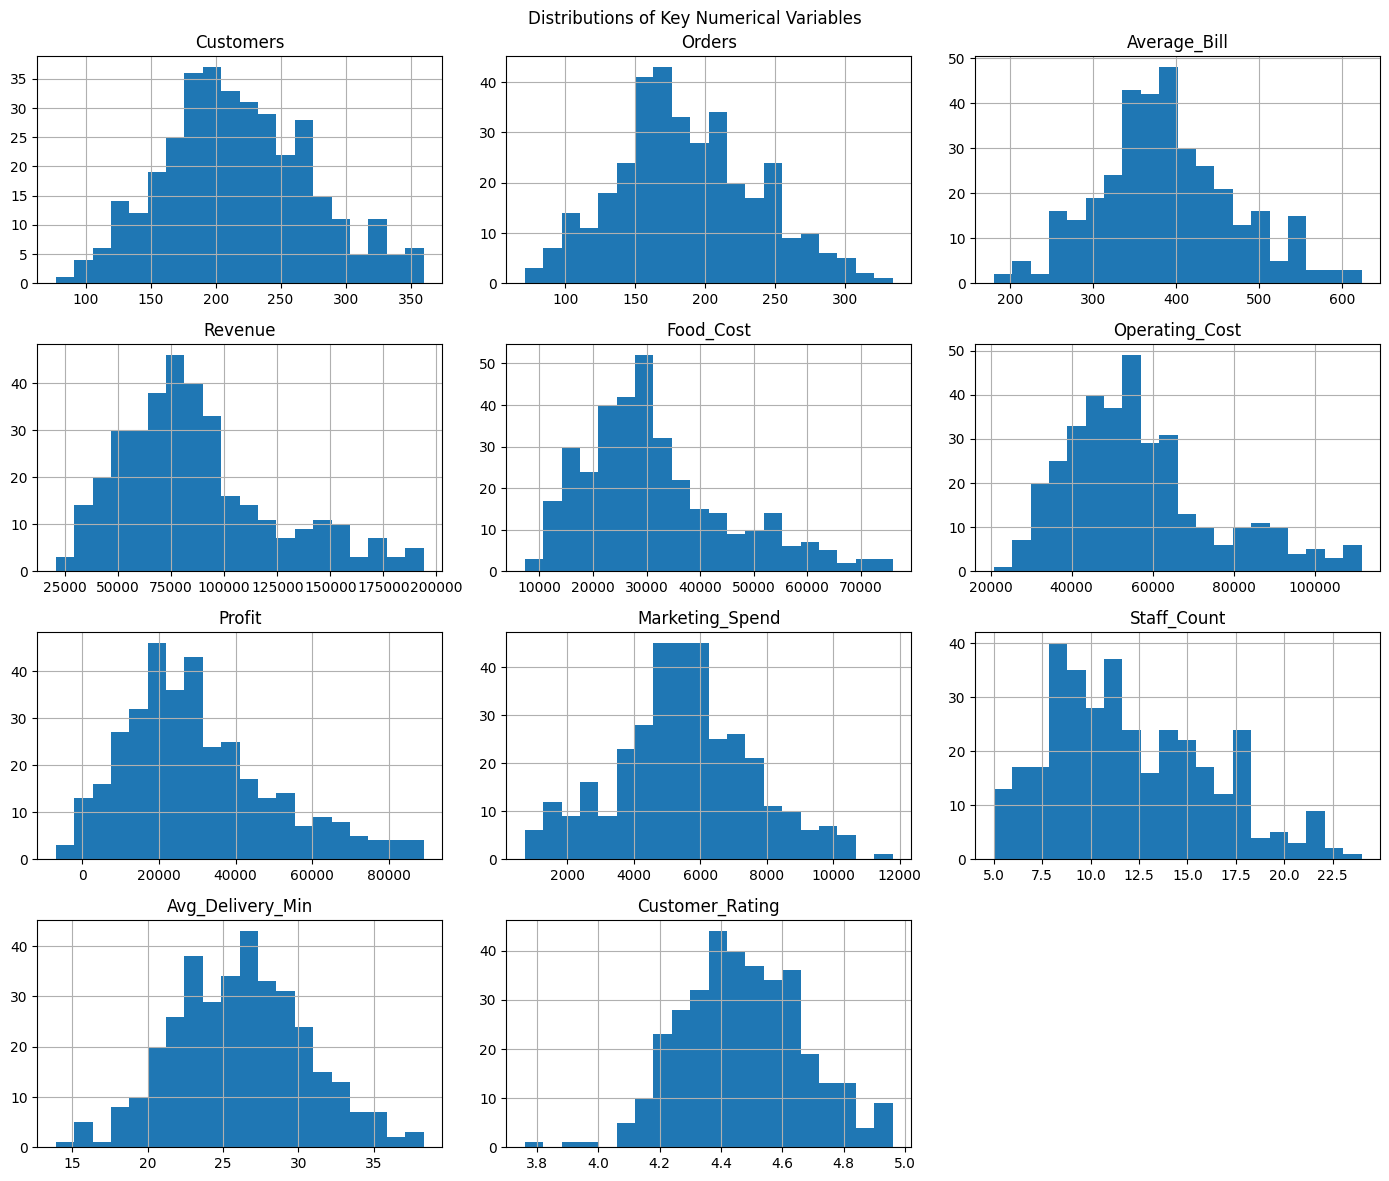

In [8]:
numeric_columns = [
    "Customers", "Orders", "Average_Bill", "Revenue",
    "Food_Cost", "Operating_Cost", "Profit",
    "Marketing_Spend", "Staff_Count", "Avg_Delivery_Min",
    "Customer_Rating"
]

df[numeric_columns].hist(figsize=(14, 12), bins=20)
plt.suptitle("Distributions of Key Numerical Variables")
plt.tight_layout()
plt.show()


## 7. Skewness Analysis

In [9]:
skewness = df[numeric_columns].skew().sort_values(ascending=False)
display(skewness.to_frame("Skewness"))


,Skewness
Food_Cost,0.925143
Operating_Cost,0.908717
Revenue,0.862027
Profit,0.809795
Staff_Count,0.526095
Average_Bill,0.309140
Orders,0.270349
Customers,0.234826
Avg_Delivery_Min,0.135023
Marketing_Spend,0.103991


## 8. Branch Performance

In [10]:
branch_summary = df.groupby("Branch").agg(
    Records=("Record_ID", "count"),
    Customers=("Customers", "sum"),
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum"),
    Avg_Rating=("Customer_Rating", "mean"),
    Avg_Delivery=("Avg_Delivery_Min", "mean")
).sort_values("Profit", ascending=False)

display(branch_summary.round(2))


,Records,Customers,Revenue,Profit,Avg_Rating,Avg_Delivery
Branch,,,,,,
Srinagar,52,11166,4510816.59,1575751.62,4.48,25.97
Bengaluru,46,10465,4173677.46,1466982.08,4.47,26.56
Jaipur,48,10717,4163815.60,1462545.76,4.47,26.58
Kochi,48,10035,4107581.66,1387297.74,4.42,25.84
Hyderabad,43,9494,3818610.68,1350328.01,4.47,25.52
Mumbai,44,9406,3554286.95,1169563.49,4.44,26.86
Pune,37,7952,3259977.12,1156826.16,4.54,25.53
Delhi,32,6847,2802363.82,1004329.45,4.49,25.69


## 9. Branch Revenue and Profit Comparison

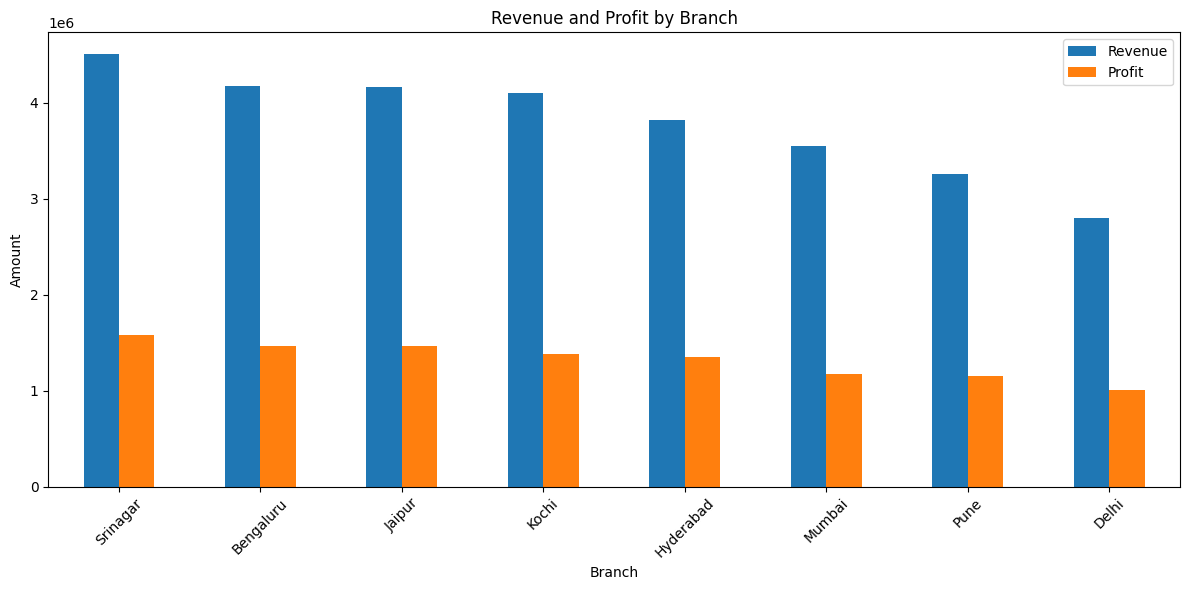

In [11]:
branch_summary[["Revenue", "Profit"]].plot(
    kind="bar", figsize=(12, 6), title="Revenue and Profit by Branch"
)
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 10. Regional Performance

In [12]:
region_summary = df.groupby("Region").agg(
    Records=("Record_ID", "count"),
    Customers=("Customers", "sum"),
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum"),
    Avg_Rating=("Customer_Rating", "mean")
).sort_values("Profit", ascending=False)

display(region_summary.round(2))


,Records,Customers,Revenue,Profit,Avg_Rating
Region,,,,,
South,137,29994,12099869.80,4204607.83,4.45
North,132,28730,11476996.01,4042626.83,4.48
West,81,17358,6814264.07,2326389.65,4.49


## 11. Store Type Performance

In [13]:
store_summary = df.groupby("Store_Type").agg(
    Records=("Record_ID", "count"),
    Customers=("Customers", "sum"),
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum"),
    Avg_Rating=("Customer_Rating", "mean"),
    Avg_Delivery=("Avg_Delivery_Min", "mean")
).sort_values("Profit", ascending=False)

display(store_summary.round(2))


,Records,Customers,Revenue,Profit,Avg_Rating,Avg_Delivery
Store_Type,,,,,,
Standard,196,44096,17104658.78,6003634.00,4.47,25.98
Premium,52,15534,7949100.29,3270292.24,4.46,26.40
Express,102,16452,5337370.81,1299698.07,4.46,26.17


## 12. Marketing Spend Analysis

,Marketing_Spend,Revenue,Profit
Region,,,
South,755312.73,12099869.80,4204607.83
North,723033.77,11476996.01,4042626.83
West,452375.21,6814264.07,2326389.65


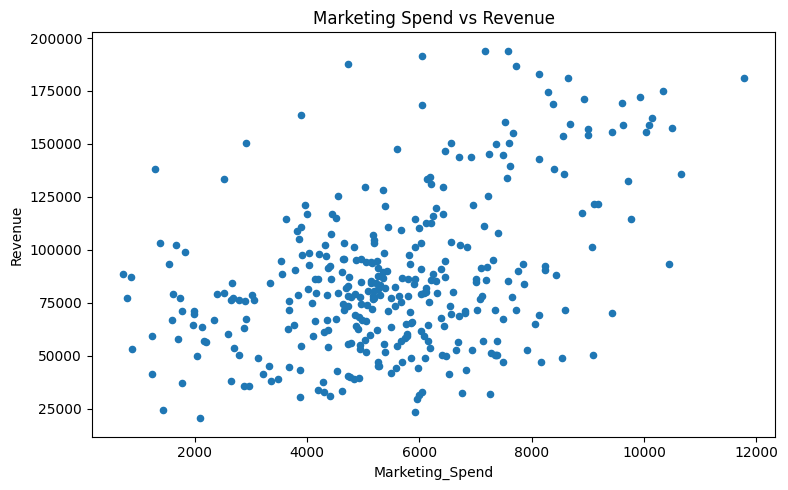

In [14]:
marketing_summary = df.groupby("Region").agg(
    Marketing_Spend=("Marketing_Spend", "sum"),
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum")
).sort_values("Marketing_Spend", ascending=False)

display(marketing_summary.round(2))

df.plot(
    x="Marketing_Spend", y="Revenue", kind="scatter",
    figsize=(8, 5), title="Marketing Spend vs Revenue"
)
plt.tight_layout()
plt.show()


## 13. Customers, Orders, and Average Bill

,count,mean,std,min,25%,50%,75%,max
Customers,350.0,217.38,56.72,77.00,180.25,213.00,255.75,360.00
Orders,350.0,187.05,50.56,71.00,155.00,182.50,218.75,334.00
Average_Bill,350.0,388.91,82.49,180.00,337.32,383.48,441.76,623.28
Revenue,350.0,86831.80,36644.45,20540.76,61261.72,79766.88,102976.18,194018.92
Profit,350.0,30210.36,19508.59,-6924.68,16915.49,26873.87,39823.74,89096.19


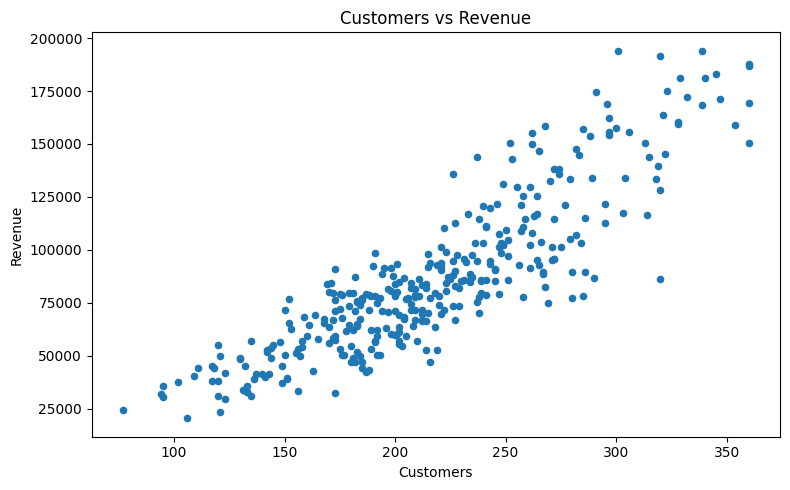

In [15]:
display(df[["Customers", "Orders", "Average_Bill", "Revenue", "Profit"]].describe().T.round(2))

df.plot(
    x="Customers", y="Revenue", kind="scatter",
    figsize=(8, 5), title="Customers vs Revenue"
)
plt.tight_layout()
plt.show()


## 14. Delivery Time and Customer Rating

,count,mean,std,min,25%,50%,75%,max
Avg_Delivery_Min,350.0,26.10,4.39,13.90,22.80,26.10,29.08,38.30
Customer_Rating,350.0,4.47,0.20,3.76,4.32,4.47,4.60,4.96


Correlation between delivery time and customer rating: -0.437


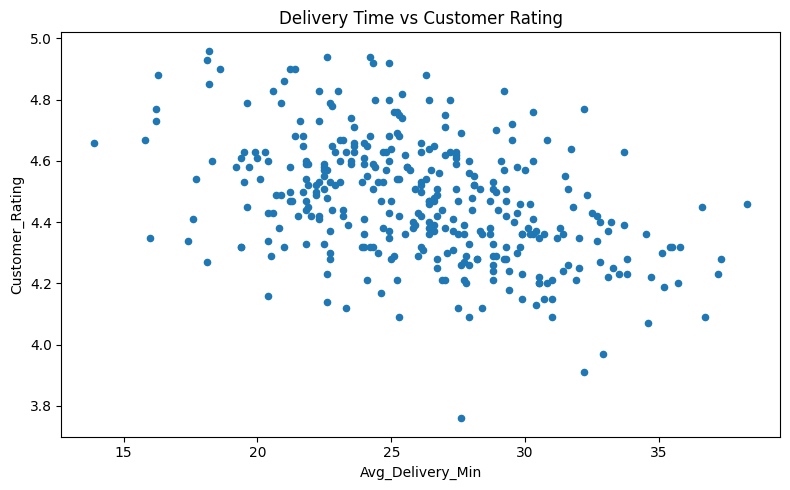

In [16]:
display(df[["Avg_Delivery_Min", "Customer_Rating"]].describe().T.round(2))

print(
    "Correlation between delivery time and customer rating:",
    round(df["Avg_Delivery_Min"].corr(df["Customer_Rating"]), 3)
)

df.plot(
    x="Avg_Delivery_Min", y="Customer_Rating", kind="scatter",
    figsize=(8, 5), title="Delivery Time vs Customer Rating"
)
plt.tight_layout()
plt.show()


## 15. Correlation Matrix

In [17]:
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()

display(correlation_matrix.round(3))


,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent
Staff_Count,1.000,0.283,0.689,0.672,0.522,0.695,0.680,0.788,0.559,-0.182,0.084,0.083,-0.018
Marketing_Spend,0.283,1.000,0.405,0.416,0.332,0.431,0.405,0.485,0.350,0.101,-0.062,0.058,-0.046
Customers,0.689,0.405,1.000,0.980,0.532,0.876,0.844,0.856,0.836,0.184,-0.048,0.002,-0.101
Orders,0.672,0.416,0.980,1.000,0.522,0.858,0.828,0.841,0.815,0.187,-0.051,0.020,-0.094
Average_Bill,0.522,0.332,0.532,0.522,1.000,0.843,0.836,0.798,0.828,-0.033,0.042,-0.049,-0.044
Revenue,0.695,0.431,0.876,0.858,0.843,1.000,0.979,0.963,0.967,0.079,0.008,-0.026,-0.091
Food_Cost,0.680,0.405,0.844,0.828,0.836,0.979,1.000,0.973,0.918,0.077,0.003,-0.028,-0.080
Operating_Cost,0.788,0.485,0.856,0.841,0.798,0.963,0.973,1.000,0.862,0.020,0.021,0.014,-0.068
Profit,0.559,0.350,0.836,0.815,0.828,0.967,0.918,0.862,1.000,0.129,-0.005,-0.063,-0.107
Avg_Delivery_Min,-0.182,0.101,0.184,0.187,-0.033,0.079,0.077,0.020,0.129,1.000,-0.437,0.005,-0.112


## 16. Correlation Matrix Visualization

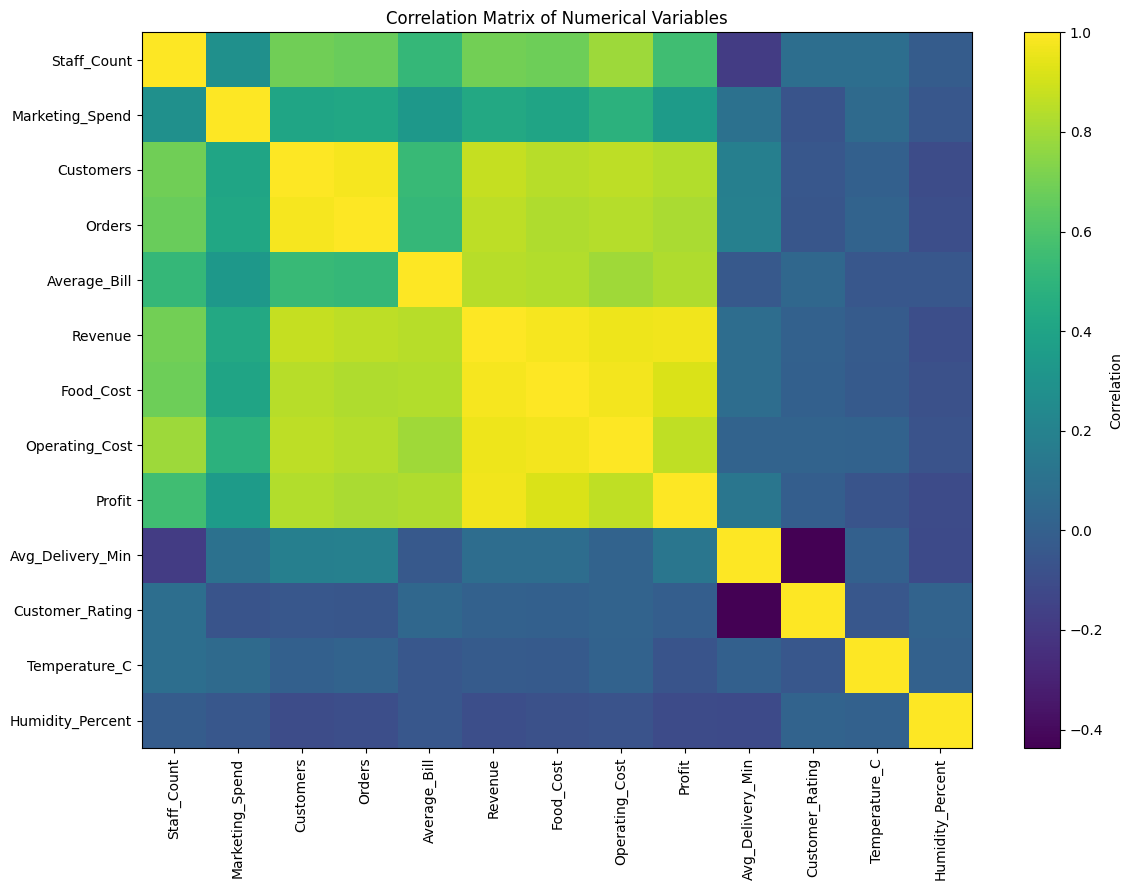

In [18]:
plt.figure(figsize=(12, 9))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()


## 17. Correlations with Revenue

In [19]:
display(
    correlation_matrix["Revenue"]
    .sort_values(ascending=False)
    .to_frame("Correlation_with_Revenue")
    .round(3)
)


,Correlation_with_Revenue
Revenue,1.000
Food_Cost,0.979
Profit,0.967
Operating_Cost,0.963
Customers,0.876
Orders,0.858
Average_Bill,0.843
Staff_Count,0.695
Marketing_Spend,0.431
Avg_Delivery_Min,0.079


## 18. Correlations with Profit

In [20]:
display(
    correlation_matrix["Profit"]
    .sort_values(ascending=False)
    .to_frame("Correlation_with_Profit")
    .round(3)
)


,Correlation_with_Profit
Profit,1.000
Revenue,0.967
Food_Cost,0.918
Operating_Cost,0.862
Customers,0.836
Average_Bill,0.828
Orders,0.815
Staff_Count,0.559
Marketing_Spend,0.350
Avg_Delivery_Min,0.129


## 19. Top Performing Records

In [21]:
print("Top 10 records by Revenue:")
display(df.sort_values("Revenue", ascending=False)[
    ["Record_ID", "Branch", "Region", "Store_Type",
     "Customers", "Revenue", "Profit", "Customer_Rating"]
].head(10))

print("\nTop 10 records by Profit:")
display(df.sort_values("Profit", ascending=False)[
    ["Record_ID", "Branch", "Region", "Store_Type",
     "Customers", "Revenue", "Profit", "Customer_Rating"]
].head(10))


Top 10 records by Revenue:


,Record_ID,Branch,Region,Store_Type,Customers,Revenue,Profit,Customer_Rating
85,ST0086,Srinagar,North,Premium,301,194018.92,82529.78,4.34
246,ST0247,Srinagar,North,Premium,339,193782.79,87017.17,4.63
323,ST0324,Delhi,North,Premium,320,191425.08,83745.96,4.54
204,ST0205,Bengaluru,South,Premium,360,187875.32,80422.67,4.36
333,ST0334,Bengaluru,South,Premium,360,186854.25,79823.25,4.72
156,ST0157,Hyderabad,South,Premium,345,182861.79,77604.99,4.65
183,ST0184,Delhi,North,Premium,329,181345.22,89096.19,4.39
111,ST0112,Kochi,South,Premium,340,181338.86,79042.43,4.16
278,ST0279,Srinagar,North,Premium,323,174925.93,65629.17,4.63
228,ST0229,Jaipur,North,Premium,291,174574.92,70366.83,4.74



Top 10 records by Profit:


,Record_ID,Branch,Region,Store_Type,Customers,Revenue,Profit,Customer_Rating
183,ST0184,Delhi,North,Premium,329,181345.22,89096.19,4.39
246,ST0247,Srinagar,North,Premium,339,193782.79,87017.17,4.63
60,ST0061,Delhi,North,Premium,296,168847.37,85383.56,4.35
171,ST0172,Kochi,South,Premium,347,171167.06,84963.97,4.67
323,ST0324,Delhi,North,Premium,320,191425.08,83745.96,4.54
85,ST0086,Srinagar,North,Premium,301,194018.92,82529.78,4.34
204,ST0205,Bengaluru,South,Premium,360,187875.32,80422.67,4.36
333,ST0334,Bengaluru,South,Premium,360,186854.25,79823.25,4.72
111,ST0112,Kochi,South,Premium,340,181338.86,79042.43,4.16
156,ST0157,Hyderabad,South,Premium,345,182861.79,77604.99,4.65


## 20. 8 Meaningful Data-Driven Observations

In [22]:
observations = [
    'The dataset contains 350 records and 22 columns; Promotion has 184 missing entries, while the other columns have no missing values.',
    'Srinagar has the highest total revenue (₹4,510,816.59) and highest total profit (₹1,575,751.62) among the branches.',
    'The South region has the highest total revenue (₹12,099,869.80) and total profit (₹4,204,607.83) among the regions.',
    'Standard stores have the highest total revenue (₹17,104,658.78) and total profit (₹6,003,634.00) among store types.',
    'Revenue has strong positive linear relationships with Customers (r=0.876), Orders (r=0.858), and Average_Bill (r=0.843).',
    'Revenue is strongly correlated with Food_Cost (r=0.979) and Operating_Cost (r=0.963); these are associations, not proof of causation.',
    'Customer_Rating has almost no linear correlation with Revenue (r=0.008) or Profit (r=-0.005).',
    'Average delivery time has a weak positive correlation with Revenue (r=0.079), while Humidity_Percent has a weak negative correlation with Revenue (r=-0.091).'
]

for i, observation in enumerate(observations, start=1):
    print(f"{i}. {observation}")


1. The dataset contains 350 records and 22 columns; Promotion has 184 missing entries, while the other columns have no missing values.
2. Srinagar has the highest total revenue (₹4,510,816.59) and highest total profit (₹1,575,751.62) among the branches.
3. The South region has the highest total revenue (₹12,099,869.80) and total profit (₹4,204,607.83) among the regions.
4. Standard stores have the highest total revenue (₹17,104,658.78) and total profit (₹6,003,634.00) among store types.
5. Revenue has strong positive linear relationships with Customers (r=0.876), Orders (r=0.858), and Average_Bill (r=0.843).
6. Revenue is strongly correlated with Food_Cost (r=0.979) and Operating_Cost (r=0.963); these are associations, not proof of causation.
7. Customer_Rating has almost no linear correlation with Revenue (r=0.008) or Profit (r=-0.005).
8. Average delivery time has a weak positive correlation with Revenue (r=0.079), while Humidity_Percent has a weak negative correlation with Revenue (

## Conclusion

The EDA identifies differences across branches, regions, and store types and uses descriptive and correlation analysis to understand relationships among customers, revenue, profit, marketing spend, staff count, delivery time, and customer ratings.
